In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("coffee_sales_uncleaned.csv")

In [3]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10.0,card,thirty eight,Latte,Morning,Fri,Mar,5.0,3.0,01-03-2024,15:50.5
1,twelve,card,NaN,Hot Chocolate,Afternoon,Fri,Mar,5.0,3.0,01-03-2024,19:22.5
2,12.0,card,38.7,lattee,Afternoon,Fri,Mar,5.0,3.0,01-03-2024,20:18.1
3,NaN,card,28.9,Americano,Afternoon,Fri,Mar,5.0,3.0,2024/03/01,46:33.0
4,13.0,card,38.7,Latte,Afternoon,Fri,Mar,5.0,3.0,01-03-2024,8pm


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3370 non-null   object 
 1   cash_type    3370 non-null   object 
 2   money        3370 non-null   object 
 3   coffee_name  3371 non-null   object 
 4   Time_of_Day  3370 non-null   object 
 5   Weekday      3370 non-null   object 
 6   Month_name   3370 non-null   object 
 7   Weekdaysort  3370 non-null   float64
 8   Monthsort    3370 non-null   float64
 9   Date         3370 non-null   object 
 10  Time         3370 non-null   object 
dtypes: float64(2), object(9)
memory usage: 304.9+ KB


In [6]:
df.describe()

,Weekdaysort,Monthsort
count,3370.000000,3370.000000
mean,3.846291,6.440059
std,1.973284,3.497715
min,1.000000,1.000000
25%,2.000000,3.000000
50%,4.000000,7.000000
75%,6.000000,10.000000
max,7.000000,12.000000


In [7]:
df.isnull().sum()

hour_of_day    177
cash_type      177
money          177
coffee_name    176
Time_of_Day    177
Weekday        177
Month_name     177
Weekdaysort    177
Monthsort      177
Date           177
Time           177
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [9]:
df.dtypes

hour_of_day     object
cash_type       object
money           object
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort    float64
Monthsort      float64
Date            object
Time            object
dtype: object

In [12]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].value_counts())


hour_of_day
hour_of_day
10.0      308
11.0      267
16.0      263
12.0      227
9.0       227
8.0       225
15.0      225
17.0      224
14.0      219
19.0      217
13.0      214
18.0      209
21.0      186
20.0      160
22.0      108
7.0        85
6.0         5
twelve      1
Name: count, dtype: int64

cash_type
cash_type
card     3369
CARD        1
Name: count, dtype: int64

money
money
35.76           960
32.82           463
25.96           441
30.86           369
27.92           314
37.72           265
23.02           198
38.7            122
28.9             86
21.06            56
33.8             50
18.12            33
24.0             12
thirty eight      1
Name: count, dtype: int64

coffee_name
coffee_name
Americano with Milk    761
Latte                  725
Americano              538
Cappuccino             465
Cortado                273
Hot Chocolate          262
Cocoa                  225
Espresso               121
lattee                   1
Name: count, dtype: int64

Time_of_

### Histogram

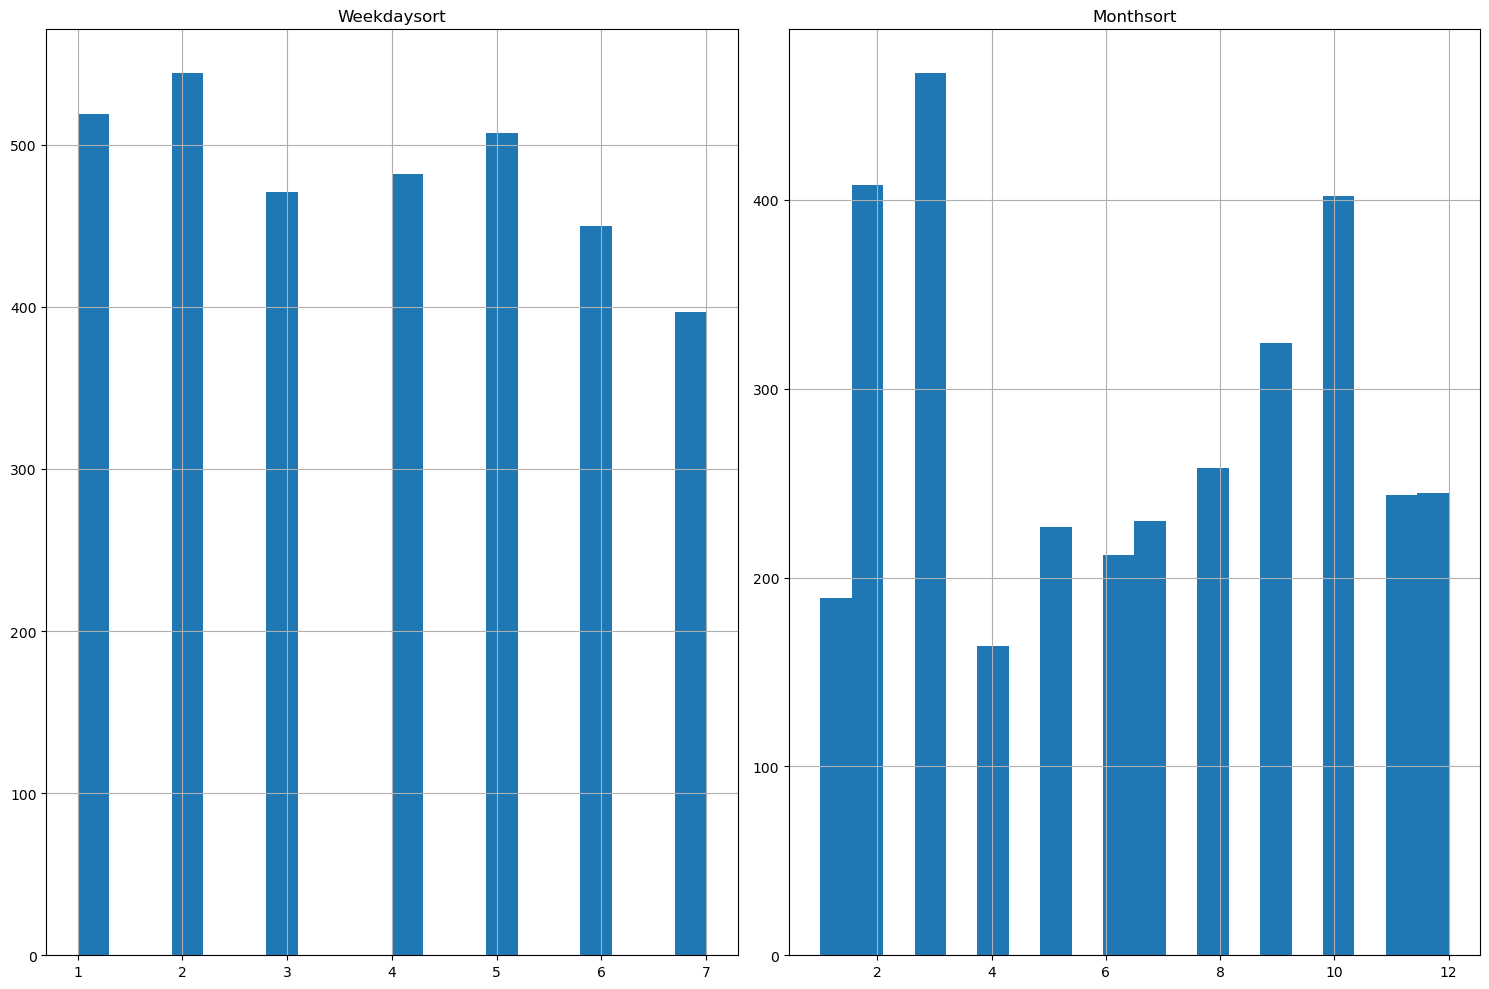

In [14]:
df.hist(figsize=(15,10), bins= 20)
plt.tight_layout()
plt.show()

### BOXplot (outlier detection)


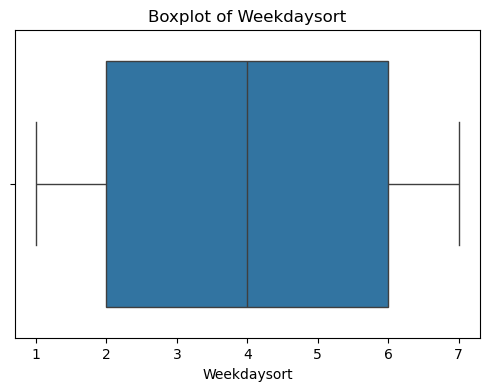

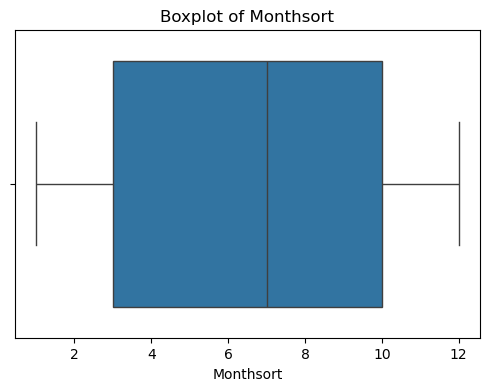

In [15]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Correlation Heatmap

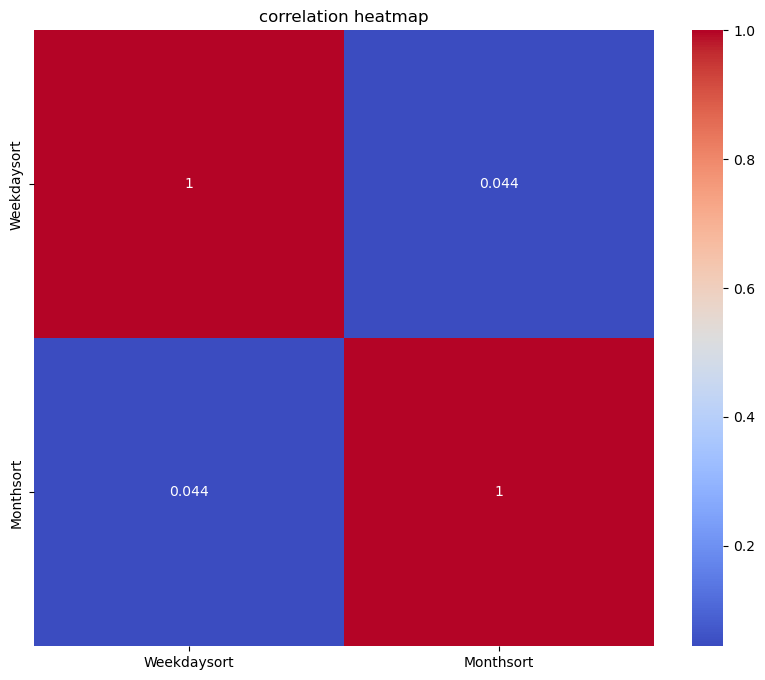

In [17]:
plt.figure(figsize = (10,8))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr,
            annot= True,
            cmap = 'coolwarm')
plt.title("correlation heatmap")
plt.show()

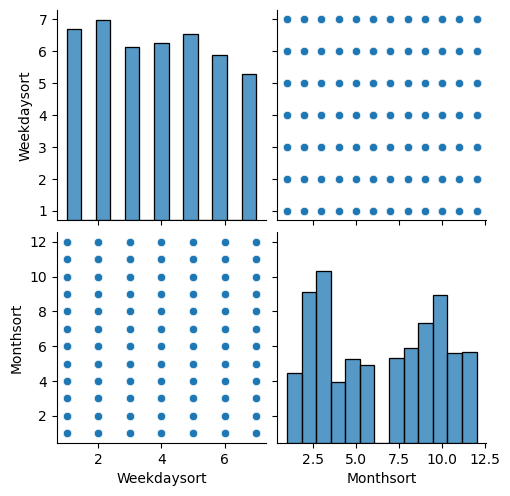

In [19]:
sns.pairplot(df.select_dtypes(include=['int64','float64']))
plt.show()

### Countplots (categorical columns)

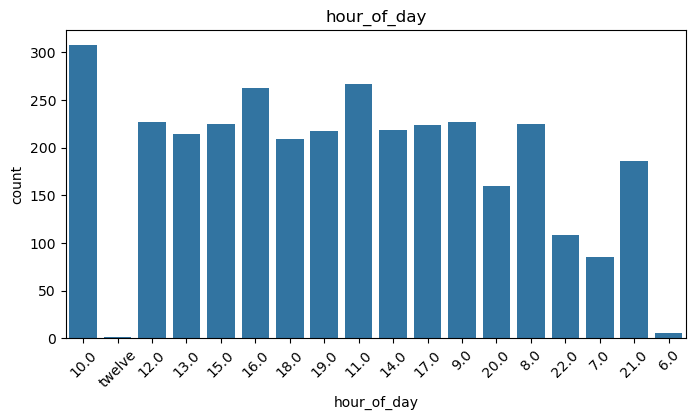

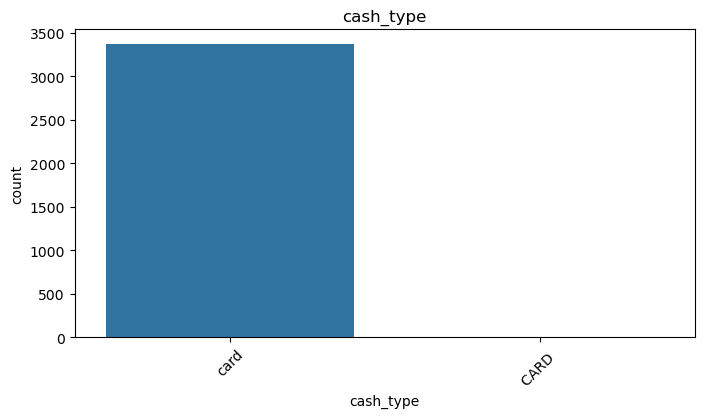

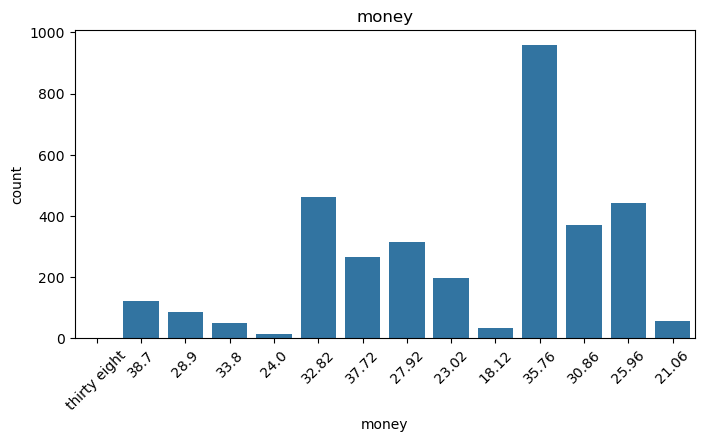

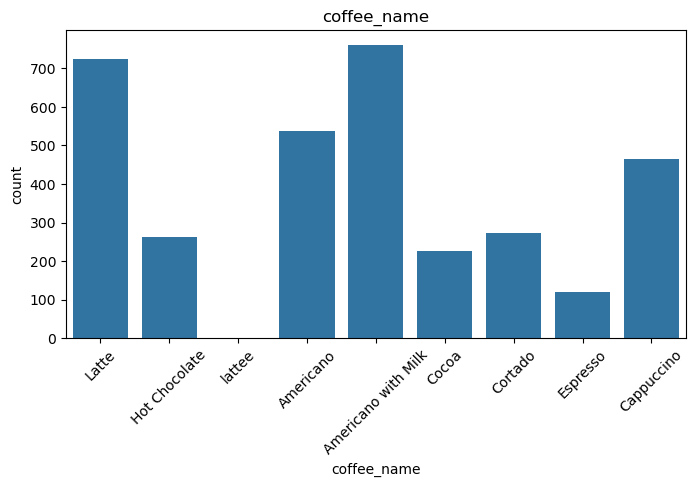

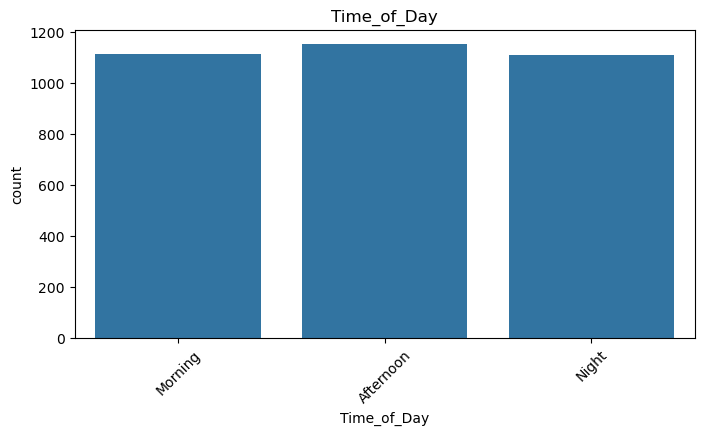

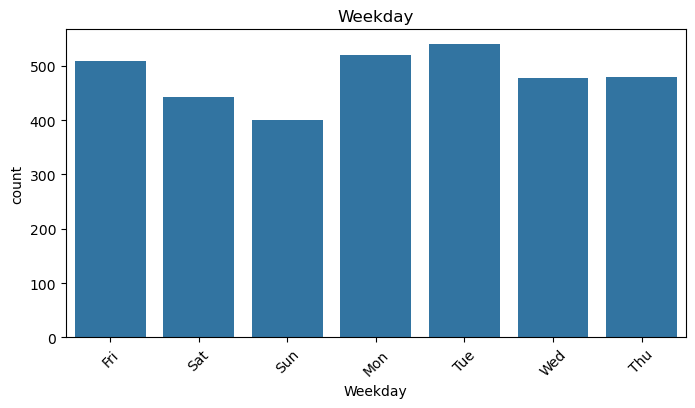

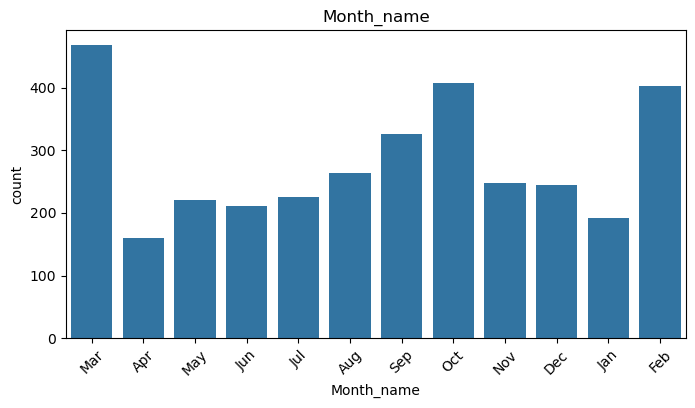

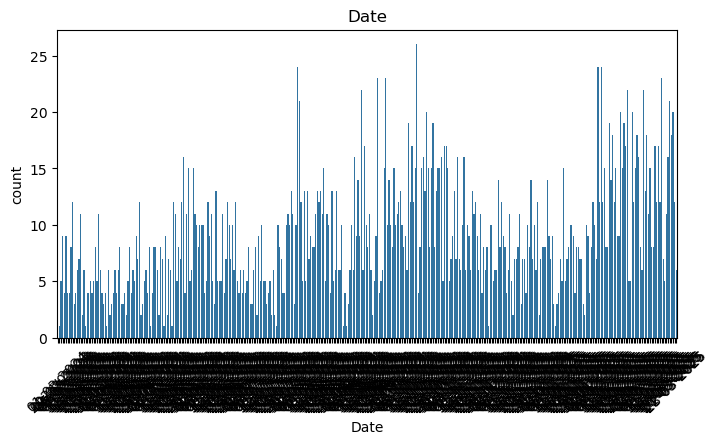

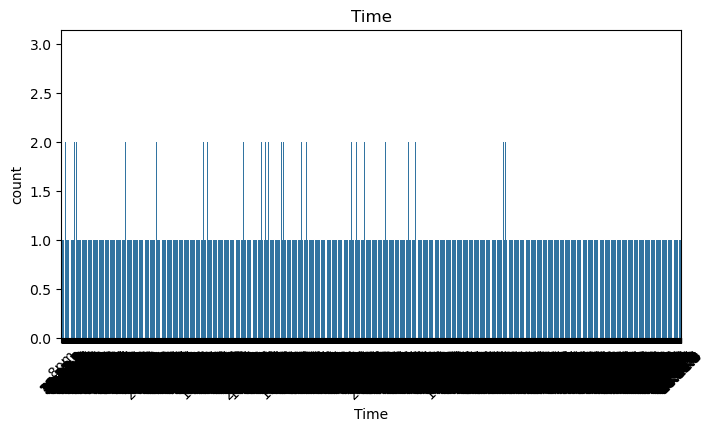

In [23]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

### Distribution PLot

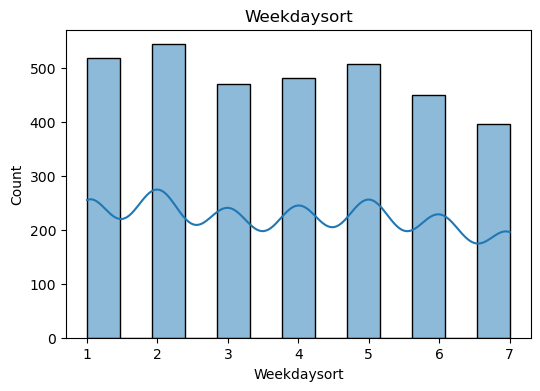

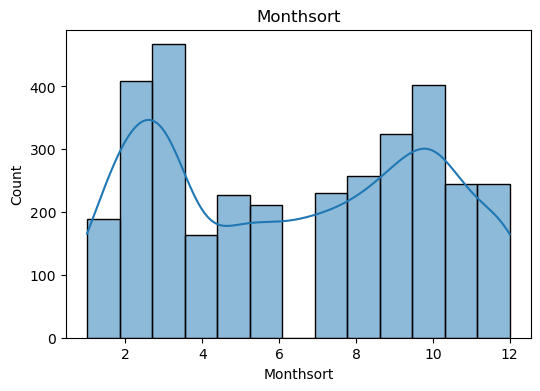

In [24]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [25]:
print(df.select_dtypes(include=['int64','float64']).skew())

Weekdaysort    0.079297
Monthsort      0.011139
dtype: float64


In [27]:
print(df.describe())

       Weekdaysort    Monthsort
count  3370.000000  3370.000000
mean      3.846291     6.440059
std       1.973284     3.497715
min       1.000000     1.000000
25%       2.000000     3.000000
50%       4.000000     7.000000
75%       6.000000    10.000000
max       7.000000    12.000000


### Business Insights